Enable GPU

In [ ]:
import torch
torch.cuda.is_available()


True

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install ultralytics torchvision seaborn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.7 MB/s eta 0:00:00


In [ ]:
!cp "/content/drive/MyDrive/Dental_Project/archive (1).zip" /content/
!unzip -q "/content/archive (1).zip" -d /content/dataset

In [ ]:
!find /content/dataset -type d -name images

/content/dataset/YOLO/YOLO/train/images
/content/dataset/YOLO/YOLO/valid/images
/content/dataset/YOLO/YOLO/test/images


In [ ]:
!ls /content/drive/MyDrive/Dental_Project


'archive (1).zip'


Copy ZIP to Colab

In [ ]:
!cp "/content/drive/MyDrive/Dental_Project/archive (1).zip" /content/


Unzip Inside Colab

In [ ]:
!unzip -q "/content/archive (1).zip" -d /content/dataset


Check Folder Structure

In [ ]:
!ls /content/dataset


best.pt  checkpoint0033_4scale.pth  COCO  YOLO


Check YOLO Folder Structure

In [ ]:
!ls /content/dataset/YOLO


YOLO


In [ ]:
!ls /content/dataset/YOLO/YOLO


data.yaml  test  train	valid


Confirm Image & Label Folders

In [ ]:
!ls /content/dataset/YOLO/YOLO/train


images	labels


In [ ]:
!ls /content/dataset/YOLO/YOLO/train/images | head


000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.76cabac5ba504297e98502d2731728d5.jpg
000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.8ffbe5dc98f1e8997ea22f5ef5abc337.jpg
003e5f80-MOHAMADI_ATEFEH_2020-06-01173808_jpg.rf.f236525d49813bc09dfbe4b139c412ac.jpg
0043783e-Asiadar_Leila_2022-06-12141026_jpg.rf.f6ffdb23ca9d38c757b7001aa84cf1e7.jpg
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.98b2e72cb9a26e75d40df97e04473ada.jpg
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.b8c24267668299d5d84e878357067cc6.jpg
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.d93e04580a7164c9e5c7ebcd57177f6a.jpg
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.f0189b6853ba7ccdec9f1cd91b58dac4.jpg
01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.171767b3f4b8c3e99f0810c1c3d31d0b.jpg
01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.93976cb5376c518410a89cbbc608a0a8.jpg


In [ ]:
!ls /content/dataset/YOLO/YOLO/train/labels | head


000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.76cabac5ba504297e98502d2731728d5.txt
000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.8ffbe5dc98f1e8997ea22f5ef5abc337.txt
003e5f80-MOHAMADI_ATEFEH_2020-06-01173808_jpg.rf.f236525d49813bc09dfbe4b139c412ac.txt
0043783e-Asiadar_Leila_2022-06-12141026_jpg.rf.f6ffdb23ca9d38c757b7001aa84cf1e7.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.98b2e72cb9a26e75d40df97e04473ada.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.b8c24267668299d5d84e878357067cc6.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.d93e04580a7164c9e5c7ebcd57177f6a.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.f0189b6853ba7ccdec9f1cd91b58dac4.txt
01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.171767b3f4b8c3e99f0810c1c3d31d0b.txt
01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.93976cb5376c518410a89cbbc608a0a8.txt


Install YOLO

In [ ]:
!pip install ultralytics -q


In [ ]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Check data.yaml

In [ ]:
!cat /content/dataset/YOLO/YOLO/data.yaml


# path: ../datasets/roboflow

train: /home/loki/DentalObjectDetection/data/YOLO/train/images
val: /home/loki/DentalObjectDetection/data/YOLO/valid/images
test: /home/loki/DentalObjectDetection/data/YOLO/valid/images

names: 
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: impacted tooth
  12: maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption 
  17: TAD
  18: abutment
  19: attrition
  20: bone defect
  21: gingival former
  22: metal band
  23: orthodontic brackets
  24: permanent retainer
  25: post - core
  26: plating
  27: wire
  28: Cyst
  29: Root resorption
  30: Primary teeth

Fix data.yaml (Very Important)

In [ ]:
%%writefile /content/dental.yaml
path: /content/dataset/YOLO/YOLO
train: train/images
val: valid/images
test: test/images

names:
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: Impacted tooth
  12: Maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption
  17: TAD
  18: Abutment
  19: Attrition
  20: Bone defect
  21: Gingival former
  22: Metal band
  23: Orthodontic brackets
  24: Permanent retainer
  25: Post-core
  26: Plating
  27: Wire
  28: Cyst
  29: Root resorption
  30: Primary teeth


Writing /content/dental.yaml


In [ ]:
!cat /content/dental.yaml


path: /content/dataset/YOLO/YOLO
train: train/images
val: valid/images
test: test/images

names:
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: Impacted tooth
  12: Maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption
  17: TAD
  18: Abutment
  19: Attrition
  20: Bone defect
  21: Gingival former
  22: Metal band
  23: Orthodontic brackets
  24: Permanent retainer
  25: Post-core
  26: Plating
  27: Wire
  28: Cyst
  29: Root resorption
  30: Primary teeth


TRAIN YOLOv11n

Load YOLOv11n Model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # nano version


Train Model (Safe Settings First)

In [ ]:
model.train(
    data="/content/dental.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

Exception in thread Thread-8 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 541, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_s

      19/30      4.41G       1.54      1.063      1.085        231        640: 74% ━━━━━━━━╸─── 437/593 1.9it/s 3:13<1:21


KeyboardInterrupt: 

In [ ]:
!cp -r runs /content/drive/MyDrive/Dental_Project/


In [ ]:
runs/detect/train/
    weights/best.pt
    weights/last.pt


SyntaxError: invalid syntax (ipython-input-2257513555.py, line 1)

Restarting from checkoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Install YOLO Again

In [ ]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.2 MB/s eta 0:00:00


Check Checkpoint Exists

In [ ]:
!ls /content/drive/MyDrive/Dental_Project/runs/detect/train/weights


best.pt  last.pt


Resume Training Properly

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Dental_Project/runs/detect/train/weights/last.pt")

model.train(resume=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou

RuntimeError: Dataset '/content/dental.yaml' error ❌ '/content/dental.yaml' does not exist

Recreate dental.yaml

In [ ]:
%%writefile /content/dental.yaml
path: /content/dataset/YOLO/YOLO
train: train/images
val: valid/images
test: test/images

names:
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: Impacted tooth
  12: Maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption
  17: TAD
  18: Abutment
  19: Attrition
  20: Bone defect
  21: Gingival former
  22: Metal band
  23: Orthodontic brackets
  24: Permanent retainer
  25: Post-core
  26: Plating
  27: Wire
  28: Cyst
  29: Root resorption
  30: Primary teeth


Writing /content/dental.yaml


Resume With Explicit Data Path

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Dental_Project/runs/detect/train/weights/last.pt")

model.train(
    data="/content/dental.yaml",
    resume=True
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Dental_Project/runs/detect/train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

RuntimeError: Dataset '/content/dental.yaml' error ❌ Dataset '/content/dental.yaml' images not found, missing path '/content/dataset/YOLO/YOLO/valid/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

Copy ZIP From Drive Again

In [ ]:
!cp "/content/drive/MyDrive/Dental_Project/archive (1).zip" /content/


Unzip Again

In [ ]:
!unzip -q "/content/archive (1).zip" -d /content/dataset


Confirm It Exists

In [ ]:
!ls /content/dataset/YOLO/YOLO/train


images	labels


Resume Again

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Dental_Project/runs/detect/train/weights/last.pt")

model.train(
    data="/content/dental.yaml",
    resume=True
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dental.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Dental_Project/runs/detect/train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 18, 21, 22, 23, 25, 27, 28, 30])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79673a9f0e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.

Install Required Libraries Again

In [ ]:
!pip install ultralytics -q
!pip install seaborn scikit-learn pytorch-grad-cam -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.5 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/runs/detect/train/weights

best.pt  last.pt


In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/Dental_Project/runs/detect/train/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Show Sample Images

In [ ]:
!ls /content/dataset

ls: cannot access '/content/dataset': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/Dental_Project"

'archive (1).zip'   runs


In [ ]:
!cp "/content/drive/MyDrive/Dental_Project/archive (1).zip" /content/

In [ ]:
!unzip -q "/content/archive (1).zip" -d /content/dataset

In [ ]:
!ls /content/dataset

best.pt  checkpoint0033_4scale.pth  COCO  YOLO


In [ ]:
!ls /content/dataset/YOLO

YOLO


In [ ]:
!ls /content/dataset/YOLO/*

data.yaml  test  train	valid


In [ ]:
!find /content/dataset -type d -name images

/content/dataset/YOLO/YOLO/train/images
/content/dataset/YOLO/YOLO/valid/images
/content/dataset/YOLO/YOLO/test/images


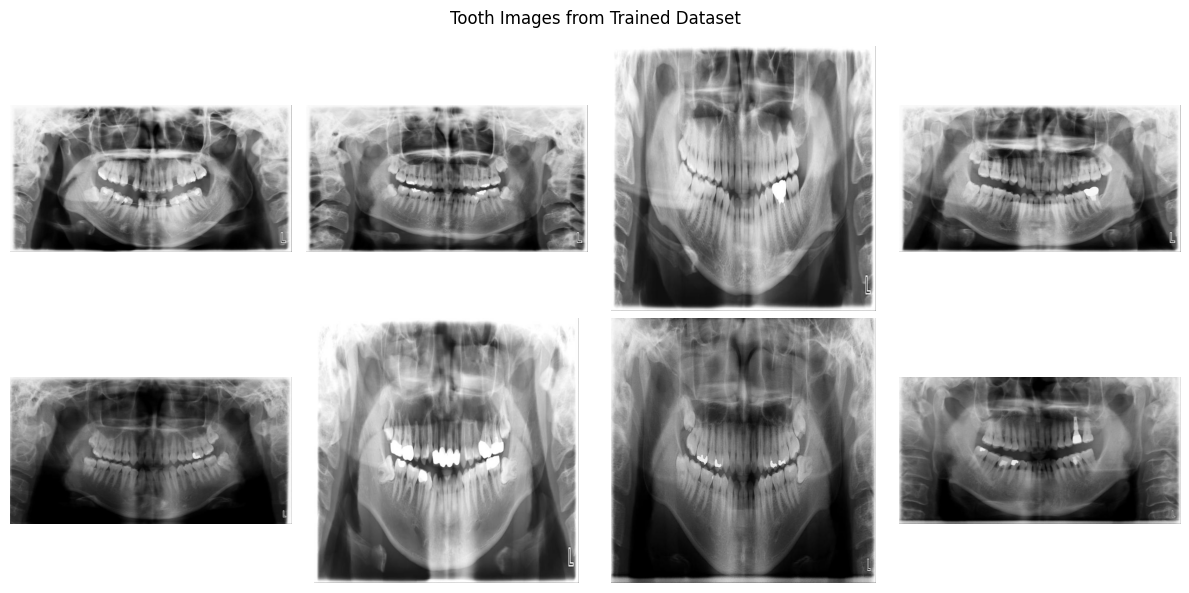

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import cv2

# ✅ Correct path (double YOLO)
train_path = "/content/dataset/YOLO/YOLO/train/images"

# Get random 8 images
images = random.sample(os.listdir(train_path), 8)

plt.figure(figsize=(12,6))

for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(train_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Tooth Images from Trained Dataset")
plt.tight_layout()
plt.show()

RESNET50

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

In [ ]:
import os
import shutil

# Paths
base_path = "/content/dataset/YOLO/YOLO"
train_img = base_path + "/train/images"
train_lbl = base_path + "/train/labels"

val_img = base_path + "/valid/images"
val_lbl = base_path + "/valid/labels"

# New classification dataset
new_base = "/content/classification_dataset"

for split in ["train", "val"]:
    for cls in ["Caries", "NonCaries"]:
        os.makedirs(f"{new_base}/{split}/{cls}", exist_ok=True)

def process_split(img_path, lbl_path, split_name):
    for file in os.listdir(img_path):
        img_file = os.path.join(img_path, file)
        label_file = os.path.join(lbl_path, file.replace(".jpg", ".txt").replace(".png", ".txt"))

        is_caries = False
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                for line in f:
                    class_id = int(line.split()[0])
                    if class_id == 0:  # Caries class
                        is_caries = True
                        break

        if is_caries:
            shutil.copy(img_file, f"{new_base}/{split_name}/Caries/")
        else:
            shutil.copy(img_file, f"{new_base}/{split_name}/NonCaries/")

# Process train and val
process_split(train_img, train_lbl, "train")
process_split(val_img, val_lbl, "val")

print("Binary dataset created successfully.")

Binary dataset created successfully.


Check Distribution

In [ ]:
for split in ["train", "val"]:
    for cls in ["Caries", "NonCaries"]:
        path = f"/content/classification_dataset/{split}/{cls}"
        print(split, cls, len(os.listdir(path)))

train Caries 2182
train NonCaries 7299
val Caries 614
val NonCaries 2257


In [ ]:
import shutil

shutil.rmtree("/content/classification_balanced", ignore_errors=True)
print("Old balanced folder deleted.")

Old balanced folder deleted.


Balance Training Data

In [ ]:
import os
import random
import shutil

base = "/content/classification_dataset/train"

caries_path = base + "/Caries"
noncaries_path = base + "/NonCaries"

balanced_base = "/content/classification_balanced/train"
os.makedirs(balanced_base + "/Caries", exist_ok=True)
os.makedirs(balanced_base + "/NonCaries", exist_ok=True)

caries_files = os.listdir(caries_path)
noncaries_files = os.listdir(noncaries_path)

# Copy ALL caries
for f in caries_files:
    shutil.copy(os.path.join(caries_path, f),
                balanced_base + "/Caries/" + f)

# Randomly select SAME number of noncaries
selected_noncaries = random.sample(noncaries_files, len(caries_files))

for f in selected_noncaries:
    shutil.copy(os.path.join(noncaries_path, f),
                balanced_base + "/NonCaries/" + f)

print("Balanced training dataset created.")

Balanced training dataset created.


Check New Counts

In [ ]:
for cls in ["Caries", "NonCaries"]:
    path = f"/content/classification_balanced/train/{cls}"
    print(cls, len(os.listdir(path)))

Caries 2182
NonCaries 2182


In [ ]:
!pip install torch torchvision scikit-learn seaborn -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Define Data Transforms

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Load Dataset

In [ ]:
train_dir = "/content/classification_balanced/train"
val_dir = "/content/classification_dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['Caries', 'NonCaries']


Load Pretrained ResNet-50

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Freeze Early Layers (Very Important)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

Define Loss & Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

Training Loop (10 Epochs First)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)

    train_acc = correct.double() / len(train_dataset)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {running_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}")

Epoch 1/10, Loss: 83.4174, Train Acc: 0.7113
Epoch 2/10, Loss: 73.2512, Train Acc: 0.7747
Epoch 3/10, Loss: 70.5493, Train Acc: 0.7814
Epoch 4/10, Loss: 68.8625, Train Acc: 0.7796
Epoch 5/10, Loss: 67.4770, Train Acc: 0.7896
Epoch 6/10, Loss: 67.8615, Train Acc: 0.7835
Epoch 7/10, Loss: 67.4935, Train Acc: 0.7862
Epoch 8/10, Loss: 66.9882, Train Acc: 0.7855
Epoch 9/10, Loss: 66.7890, Train Acc: 0.7940
Epoch 10/10, Loss: 65.8488, Train Acc: 0.7963


Unfreeze Last Block

In [ ]:
# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

New Optimizer (Lower LR)

In [ ]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

Train 10 More Epochs

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)

    train_acc = correct.double() / len(train_dataset)

    print(f"FineTune Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {running_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}")

FineTune Epoch 1/10, Loss: 64.2544, Train Acc: 0.7963
FineTune Epoch 2/10, Loss: 59.6869, Train Acc: 0.8128
FineTune Epoch 3/10, Loss: 56.5245, Train Acc: 0.8226
FineTune Epoch 4/10, Loss: 53.1213, Train Acc: 0.8368
FineTune Epoch 5/10, Loss: 50.5119, Train Acc: 0.8423
FineTune Epoch 6/10, Loss: 46.6156, Train Acc: 0.8618
FineTune Epoch 7/10, Loss: 44.8807, Train Acc: 0.8694
FineTune Epoch 8/10, Loss: 39.7529, Train Acc: 0.8877
FineTune Epoch 9/10, Loss: 37.9250, Train Acc: 0.8868
FineTune Epoch 10/10, Loss: 35.1936, Train Acc: 0.8994


Evaluate On Validation Set

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

from sklearn.metrics import accuracy_score
val_acc = accuracy_score(all_labels, all_preds)

print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.810518982932776


Plot Training & Validation Curves

In [ ]:
train_acc_history = []
val_acc_history = []

In [ ]:
train_acc_history.append(train_acc.item())

In [ ]:
train_acc_history.append(train_acc.item())

# validation inside epoch
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = correct / total
val_acc_history.append(val_acc)

model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
print(len(train_acc_history))
print(len(val_acc_history))
print(train_acc_history)
print(val_acc_history)

1
1
[0.8994042163153071]
[0.810518982932776]


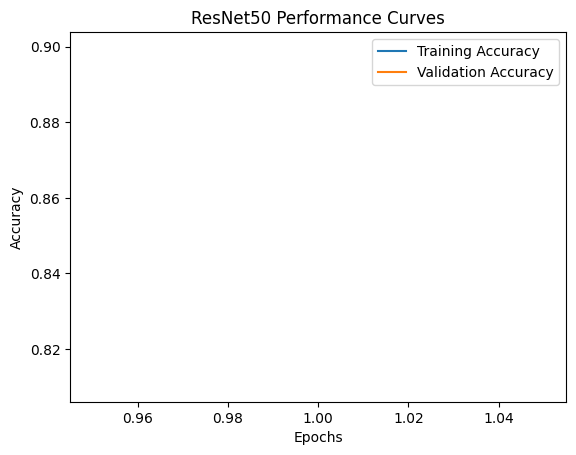

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history)+1)

plt.figure()
plt.plot(epochs, train_acc_history, label="Training Accuracy")
plt.plot(epochs, val_acc_history, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ResNet50 Performance Curves")
plt.show()

del before

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
train_acc_history = []
val_acc_history = []

In [ ]:
train_acc_history.append(train_acc.item())

# validation inside epoch
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = correct / total
val_acc_history.append(val_acc)

model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

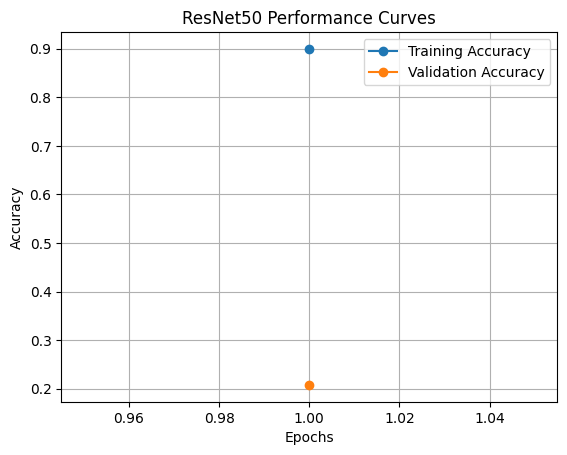

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history)+1)

plt.figure()
plt.plot(epochs, train_acc_history, marker='o', label="Training Accuracy")
plt.plot(epochs, val_acc_history, marker='o', label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ResNet50 Performance Curves")
plt.grid(True)
plt.show()

In [ ]:
train_acc_history = []
val_acc_history = []

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze FC
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 20

for epoch in range(num_epochs):

    # Unfreeze layer4 after 10 epochs
    if epoch == 10:
        for param in model.layer4.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-5
        )

    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/20 - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

Epoch 1/20 - Train Acc: 0.6957 - Val Acc: 0.8133
Epoch 2/20 - Train Acc: 0.7777 - Val Acc: 0.8144
Epoch 3/20 - Train Acc: 0.7819 - Val Acc: 0.8680
Epoch 4/20 - Train Acc: 0.7864 - Val Acc: 0.8718
Epoch 5/20 - Train Acc: 0.7880 - Val Acc: 0.8551
Epoch 6/20 - Train Acc: 0.7825 - Val Acc: 0.8777
Epoch 7/20 - Train Acc: 0.7942 - Val Acc: 0.8708
Epoch 8/20 - Train Acc: 0.7947 - Val Acc: 0.8774
Epoch 9/20 - Train Acc: 0.7931 - Val Acc: 0.8784
Epoch 10/20 - Train Acc: 0.8000 - Val Acc: 0.8676
Epoch 11/20 - Train Acc: 0.8011 - Val Acc: 0.8781
Epoch 12/20 - Train Acc: 0.8146 - Val Acc: 0.8788
Epoch 13/20 - Train Acc: 0.8210 - Val Acc: 0.8676
Epoch 14/20 - Train Acc: 0.8291 - Val Acc: 0.8666
Epoch 15/20 - Train Acc: 0.8428 - Val Acc: 0.8669
Epoch 16/20 - Train Acc: 0.8501 - Val Acc: 0.8746
Epoch 17/20 - Train Acc: 0.8671 - Val Acc: 0.8478
Epoch 18/20 - Train Acc: 0.8740 - Val Acc: 0.8683
Epoch 19/20 - Train Acc: 0.8841 - Val Acc: 0.8488
Epoch 20/20 - Train Acc: 0.9001 - Val Acc: 0.8774


Save Checkpoint to Drive
---



In [ ]:
checkpoint_path = "/content/drive/MyDrive/resnet50_caries_checkpoint.pth"

torch.save({
    "model_state_dict": model.state_dict(),
}, checkpoint_path)

print("Checkpoint saved to Google Drive successfully.")

Checkpoint saved to Google Drive successfully.


🌙 Tomorrow (From Any Device)

1️⃣ Mount Drive again

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

2️⃣ Recreate model architecture

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

3️⃣ Load weights from Drive

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/resnet50_caries_checkpoint.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model restored successfully.")

restart

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, shear=10, scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dir = "/content/classification_balanced/train"
val_dir = "/content/classification_dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)

FileNotFoundError: [Errno 2] No such file or directory: '/content/classification_balanced/train'

In [ ]:
!ls /content
!ls /content/dataset
!ls /content/dataset/YOLO/YOLO

'archive (1).zip'   dataset   drive   sample_data
best.pt  checkpoint0033_4scale.pth  COCO  YOLO
data.yaml  test  train	valid


In [ ]:
!ls /content/dataset/YOLO/YOLO/train/labels | head

000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.76cabac5ba504297e98502d2731728d5.txt
000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.8ffbe5dc98f1e8997ea22f5ef5abc337.txt
003e5f80-MOHAMADI_ATEFEH_2020-06-01173808_jpg.rf.f236525d49813bc09dfbe4b139c412ac.txt
0043783e-Asiadar_Leila_2022-06-12141026_jpg.rf.f6ffdb23ca9d38c757b7001aa84cf1e7.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.98b2e72cb9a26e75d40df97e04473ada.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.b8c24267668299d5d84e878357067cc6.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.d93e04580a7164c9e5c7ebcd57177f6a.txt
00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.f0189b6853ba7ccdec9f1cd91b58dac4.txt
01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.171767b3f4b8c3e99f0810c1c3d31d0b.txt
01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.93976cb5376c518410a89cbbc608a0a8.txt


In [ ]:
!head /content/dataset/YOLO/YOLO/train/labels/$(ls /content/dataset/YOLO/YOLO/train/labels | head -n 1)

2 0.32449374984520124 0.49987499999999996 0.3218531250773993 0.4874 0.31430937523219815 0.48809375 0.30865156222910217 0.4832421869047619 0.2992218749226006 0.477696875 0.2905468749226006 0.484628125 0.28564374984520124 0.519975 0.2837578123839009 0.5476984380952381 0.28639843777089785 0.5615609369047619 0.29205625015479875 0.57265 0.304125 0.582353125 0.3154406247678018 0.5719562499999999 0.30902968730650154 0.55255 0.3128 0.5393812499999999 0.31958906253869973 0.5282921880952381 0.32411562476780187 0.516509375 0.32449374984520124 0.49987499999999996
2 0.360325 0.5185890619047618 0.3539125003095975 0.523440625 0.3497640625386997 0.5373015619047619 0.3527812501547988 0.549778125 0.3557984377708978 0.575421875 0.3584390625386997 0.5788875 0.36221093746130034 0.5941359369047619 0.3686218749226006 0.5913625 0.3739031250773994 0.57819375 0.37541093746130033 0.568490625 0.3723937498452012 0.55255 0.3697531250773994 0.535915625 0.3644734377708978 0.5282921880952381 0.360325 0.518589061904761

In [ ]:
import os
import shutil

yolo_train_img = "/content/dataset/YOLO/YOLO/train/images"
yolo_train_lbl = "/content/dataset/YOLO/YOLO/train/labels"

yolo_val_img = "/content/dataset/YOLO/YOLO/valid/images"
yolo_val_lbl = "/content/dataset/YOLO/YOLO/valid/labels"

base_path = "/content/classification_dataset"
train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")

for folder in [train_path, val_path]:
    os.makedirs(os.path.join(folder, "Caries"), exist_ok=True)
    os.makedirs(os.path.join(folder, "NonCaries"), exist_ok=True)

def process_split(img_path, lbl_path, save_path):
    for file in os.listdir(lbl_path):
        label_file = os.path.join(lbl_path, file)
        image_file = os.path.join(img_path, file.replace(".txt", ".jpg"))

        if not os.path.exists(image_file):
            continue

        with open(label_file, "r") as f:
            lines = f.readlines()

        is_caries = any(line.strip().startswith("0 ") for line in lines)

        if is_caries:
            shutil.copy(image_file, os.path.join(save_path, "Caries"))
        else:
            shutil.copy(image_file, os.path.join(save_path, "NonCaries"))

process_split(yolo_train_img, yolo_train_lbl, train_path)
process_split(yolo_val_img, yolo_val_lbl, val_path)

print("Binary classification dataset created successfully.")

Binary classification dataset created successfully.


In [ ]:
print("Train Caries:", len(os.listdir("/content/classification_dataset/train/Caries")))
print("Train NonCaries:", len(os.listdir("/content/classification_dataset/train/NonCaries")))
print("Val Caries:", len(os.listdir("/content/classification_dataset/val/Caries")))
print("Val NonCaries:", len(os.listdir("/content/classification_dataset/val/NonCaries")))

Train Caries: 2182
Train NonCaries: 7299
Val Caries: 614
Val NonCaries: 2257


In [ ]:
train_dir = "/content/classification_dataset/train"
val_dir = "/content/classification_dataset/val"

In [ ]:
import torch

caries_count = 2182
noncaries_count = 7299

total = caries_count + noncaries_count

weight_caries = total / (2 * caries_count)
weight_noncaries = total / (2 * noncaries_count)

class_weights = torch.tensor([weight_caries, weight_noncaries]).to(device)

print(class_weights)

tensor([2.1725, 0.6495], device='cuda:0')


In [ ]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s]


In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

Create Balanced Dataset Again



In [ ]:
import os
import shutil
import random

# Source dataset
train_src = "/content/classification_dataset/train"

# New balanced dataset
balanced_base = "/content/classification_balanced"
train_bal = os.path.join(balanced_base, "train")

os.makedirs(os.path.join(train_bal, "Caries"), exist_ok=True)
os.makedirs(os.path.join(train_bal, "NonCaries"), exist_ok=True)

# Get image lists
caries_imgs = os.listdir(os.path.join(train_src, "Caries"))
noncaries_imgs = os.listdir(os.path.join(train_src, "NonCaries"))

# Shuffle noncaries
random.shuffle(noncaries_imgs)

# Keep only 2182 noncaries
noncaries_selected = noncaries_imgs[:2182]

# Copy caries (all 2182)
for img in caries_imgs:
    shutil.copy(os.path.join(train_src, "Caries", img),
                os.path.join(train_bal, "Caries"))

# Copy selected noncaries (2182)
for img in noncaries_selected:
    shutil.copy(os.path.join(train_src, "NonCaries", img),
                os.path.join(train_bal, "NonCaries"))

print("Balanced 2182 vs 2182 dataset created.")

Balanced 2182 vs 2182 dataset created.


In [ ]:
for cls in ["Caries", "NonCaries"]:
    path = f"/content/classification_balanced/train/{cls}"
    print(cls, len(os.listdir(path)))

Caries 2182
NonCaries 7299


In [ ]:
import shutil

# Delete old balanced folder completely
shutil.rmtree("/content/classification_balanced", ignore_errors=True)

print("Old balanced folder deleted.")

Old balanced folder deleted.


In [ ]:
import os
import shutil
import random

train_src = "/content/classification_dataset/train"
balanced_base = "/content/classification_balanced"
train_bal = os.path.join(balanced_base, "train")

os.makedirs(os.path.join(train_bal, "Caries"), exist_ok=True)
os.makedirs(os.path.join(train_bal, "NonCaries"), exist_ok=True)

caries_imgs = os.listdir(os.path.join(train_src, "Caries"))
noncaries_imgs = os.listdir(os.path.join(train_src, "NonCaries"))

random.shuffle(noncaries_imgs)
noncaries_selected = noncaries_imgs[:2182]

# Copy
for img in caries_imgs:
    shutil.copy(os.path.join(train_src, "Caries", img),
                os.path.join(train_bal, "Caries"))

for img in noncaries_selected:
    shutil.copy(os.path.join(train_src, "NonCaries", img),
                os.path.join(train_bal, "NonCaries"))

print("Balanced 2182 vs 2182 dataset created cleanly.")

Balanced 2182 vs 2182 dataset created cleanly.


In [ ]:
for cls in ["Caries", "NonCaries"]:
    path = f"/content/classification_balanced/train/{cls}"
    print(cls, len(os.listdir(path)))

Caries 2182
NonCaries 2182


In [ ]:
train_dir = "/content/classification_balanced/train"
val_dir = "/content/classification_dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)

['Caries', 'NonCaries']


Freeze Backbone (LIKE BEFORE)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

Optimizer (Only FC)

In [ ]:
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

Train 10 Epochs (Phase 1)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)

    train_acc = correct.double() / len(train_dataset)

    print(f"Phase1 Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {running_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}")

Phase1 Epoch 1/10, Loss: 61.5946, Train Acc: 0.5940
Phase1 Epoch 2/10, Loss: 59.4819, Train Acc: 0.6432
Phase1 Epoch 3/10, Loss: 60.4555, Train Acc: 0.6455
Phase1 Epoch 4/10, Loss: 56.8039, Train Acc: 0.6606
Phase1 Epoch 5/10, Loss: 55.8238, Train Acc: 0.6673
Phase1 Epoch 6/10, Loss: 57.7101, Train Acc: 0.6648
Phase1 Epoch 7/10, Loss: 56.6296, Train Acc: 0.6719
Phase1 Epoch 8/10, Loss: 57.9657, Train Acc: 0.6618
Phase1 Epoch 9/10, Loss: 56.1565, Train Acc: 0.6696
Phase1 Epoch 10/10, Loss: 56.2295, Train Acc: 0.6659


Saved Checkpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Recreate Model Architecture

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cpu")  # since no GPU

model = models.resnet50(pretrained=False)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Load Checkpoint

In [ ]:
checkpoint_path = "/content/drive/MyDrive/resnet50_caries_checkpoint.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Checkpoint loaded successfully!")

Checkpoint loaded successfully!


Make Sure Validation Loader Exists

In [ ]:
!ls /content/drive/MyDrive

'Colab Notebooks'   Dental_Project   resnet50_caries_checkpoint.pth


In [ ]:
!ls /content/drive/MyDrive/Dental_Project

'archive (1).zip'   runs


In [ ]:
!unzip -q "/content/drive/MyDrive/Dental_Project/archive (1).zip" -d /content/

In [ ]:
!ls /content

best.pt  checkpoint0033_4scale.pth  COCO  drive  sample_data  YOLO


In [ ]:
!ls /content/YOLO

YOLO


In [ ]:
!ls /content/YOLO/YOLO

data.yaml  test  train	valid


In [ ]:
import os
import shutil

base_path = "/content/YOLO/YOLO"

val_img = base_path + "/valid/images"
val_lbl = base_path + "/valid/labels"

new_val_base = "/content/val_binary"

os.makedirs(new_val_base + "/Caries", exist_ok=True)
os.makedirs(new_val_base + "/NonCaries", exist_ok=True)

for file in os.listdir(val_img):
    img_file = os.path.join(val_img, file)
    label_file = os.path.join(val_lbl, file.replace(".jpg", ".txt").replace(".png", ".txt"))

    is_caries = False

    if os.path.exists(label_file):
        with open(label_file, "r") as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id == 0:  # Caries class
                    is_caries = True
                    break

    if is_caries:
        shutil.copy(img_file, new_val_base + "/Caries/")
    else:
        shutil.copy(img_file, new_val_base + "/NonCaries/")

print("Validation binary dataset created.")

Validation binary dataset created.


In [ ]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

val_dir = "/content/val_binary"

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Validation samples:", len(val_dataset))

Validation samples: 2871


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_acc = correct / total
print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.8773946360153256


Get Predictions + Probabilities

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import torch.nn.functional as F

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())  # probability of Caries class

print("Predictions collected.")

Predictions collected.


EPOCH GRAPH

In [ ]:
train_acc_history = [
0.6957, 0.7777, 0.7819, 0.7864, 0.7880,
0.7825, 0.7942, 0.7947, 0.7931, 0.8000,
0.8011, 0.8146, 0.8210, 0.8291, 0.8428,
0.8501, 0.8671, 0.8740, 0.8841, 0.9001
]

val_acc_history = [
0.8133, 0.8144, 0.8680, 0.8718, 0.8551,
0.8777, 0.8708, 0.8774, 0.8784, 0.8676,
0.8781, 0.8788, 0.8676, 0.8666, 0.8669,
0.8746, 0.8478, 0.8683, 0.8488, 0.8774
]

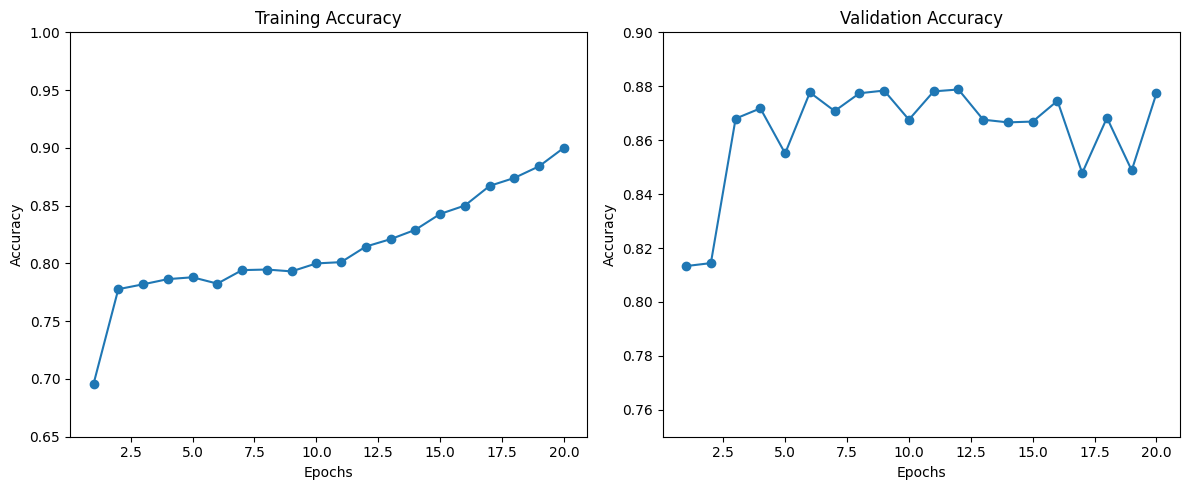

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

plt.figure(figsize=(12,5))

# Training plot
plt.subplot(1,2,1)
plt.plot(epochs, train_acc_history, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.ylim(0.65, 1.0)

# Validation plot
plt.subplot(1,2,2)
plt.plot(epochs, val_acc_history, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.ylim(0.75, 0.9)

plt.tight_layout()
plt.show()

Confusion Matrix

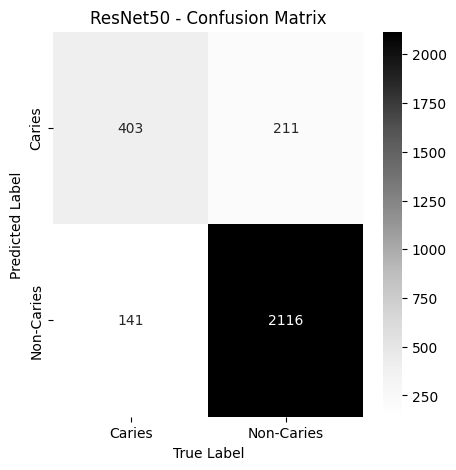

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys',
            xticklabels=["Caries","Non-Caries"],
            yticklabels=["Caries","Non-Caries"])

plt.xlabel("True Label")
plt.ylabel("Predicted Label")
plt.title("ResNet50 - Confusion Matrix")
plt.show()

ROC Curve + AUC

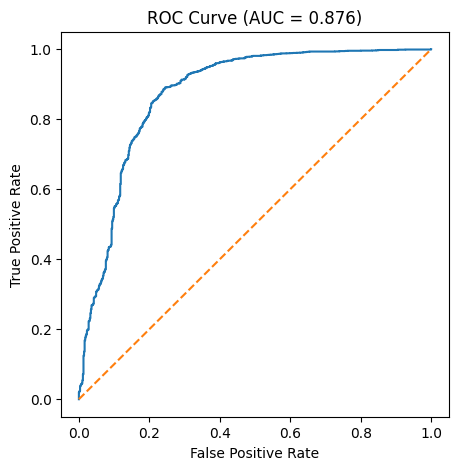

AUC Score: 0.8756279775263061


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()

print("AUC Score:", roc_auc)

Generate Proper Diagram Image

In [ ]:
!pip install torchviz

In [ ]:
from torchviz import make_dot
import torch

x = torch.randn(1,3,224,224).to(device)
y = model(x)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.format = 'png'
dot.render("resnet50_architecture")

'resnet50_architecture.png'

In [ ]:
from google.colab import files
files.download("/content/resnet50_architecture.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!apt-get install graphviz -y
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from graphviz import Digraph

dot = Digraph(format='png')
dot.attr(rankdir='LR', size='12')

# Input
dot.node('Input', 'Input Image\n224x224x3')

# Initial layers
dot.node('Conv1', 'Conv 7x7\n64 filters\nStride 2')
dot.node('Pool', 'MaxPool\n3x3')

# Residual blocks
dot.node('Res2', 'Residual Block\nConv2_x\n(3 blocks)')
dot.node('Res3', 'Residual Block\nConv3_x\n(4 blocks)')
dot.node('Res4', 'Residual Block\nConv4_x\n(6 blocks)')
dot.node('Res5', 'Residual Block\nConv5_x\n(3 blocks)')

# Final layers
dot.node('AvgPool', 'Global Avg Pool')
dot.node('FC', 'Fully Connected\n(2 Classes)')
dot.node('Output', 'Output\nCaries / Non-Caries')

# Connections
dot.edges([
    ('Input','Conv1'),
    ('Conv1','Pool'),
    ('Pool','Res2'),
    ('Res2','Res3'),
    ('Res3','Res4'),
    ('Res4','Res5'),
    ('Res5','AvgPool'),
    ('AvgPool','FC'),
    ('FC','Output')
])

dot.render('ResNet50_Block_Diagram')

'ResNet50_Block_Diagram.png'

In [ ]:
from google.colab import files
files.download("ResNet50_Block_Diagram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Generate Figure

In [ ]:
!ls /content/YOLO/YOLO

data.yaml  test  train	valid


In [ ]:
!ls /content/YOLO/YOLO/test


images	labels


In [ ]:
!cat /content/YOLO/YOLO/data.yaml

# path: ../datasets/roboflow

train: /home/loki/DentalObjectDetection/data/YOLO/train/images
val: /home/loki/DentalObjectDetection/data/YOLO/valid/images
test: /home/loki/DentalObjectDetection/data/YOLO/valid/images

names: 
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: impacted tooth
  12: maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption 
  17: TAD
  18: abutment
  19: attrition
  20: bone defect
  21: gingival former
  22: metal band
  23: orthodontic brackets
  24: permanent retainer
  25: post - core
  26: plating
  27: wire
  28: Cyst
  29: Root resorption
  30: Primary teeth

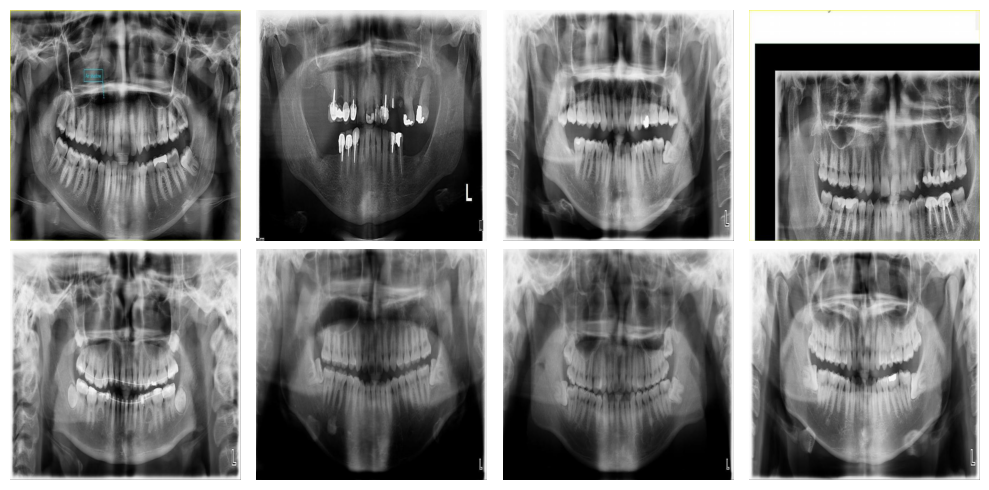

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

base_path = "/content/YOLO/YOLO/test"
image_path = os.path.join(base_path, "images")
label_path = os.path.join(base_path, "labels")

caries_imgs = []
noncaries_imgs = []

# Loop through label files
for label_file in os.listdir(label_path):
    with open(os.path.join(label_path, label_file), "r") as f:
        lines = f.readlines()
        classes = [int(line.split()[0]) for line in lines]

        if 0 in classes:
            caries_imgs.append(label_file.replace(".txt", ".jpg"))
        else:
            noncaries_imgs.append(label_file.replace(".txt", ".jpg"))

# Select 4 random from each
caries_sample = random.sample(caries_imgs, 4)
noncaries_sample = random.sample(noncaries_imgs, 4)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

# Caries row
for i, img_name in enumerate(caries_sample):
    img = Image.open(os.path.join(image_path, img_name)).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].axis("off")

# Non-Caries row
for i, img_name in enumerate(noncaries_sample):
    img = Image.open(os.path.join(image_path, img_name)).convert("RGB")
    axes[1, i].imshow(img)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("Tooth_Samples_Figure.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("Tooth_Samples_Figure.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

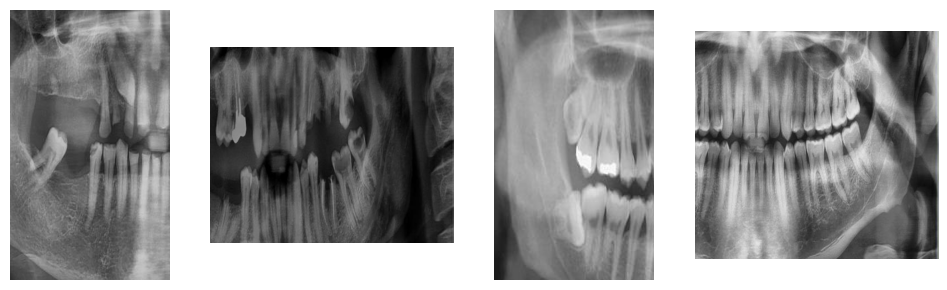

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

base_path = "/content/YOLO/YOLO/test"
image_path = os.path.join(base_path, "images")
label_path = os.path.join(base_path, "labels")

caries_crops = []

for label_file in os.listdir(label_path):
    with open(os.path.join(label_path, label_file), "r") as f:
        lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])

            if class_id == 0:  # Caries
                img_name = label_file.replace(".txt", ".jpg")
                img = Image.open(os.path.join(image_path, img_name)).convert("RGB")
                img_np = np.array(img)

                h, w, _ = img_np.shape

                # ONLY take first 4 values after class
                x_center, y_center, bw, bh = map(float, parts[1:5])

                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)

                pad = 10
                x1 = max(0, x1 - pad)
                y1 = max(0, y1 - pad)
                x2 = min(w, x2 + pad)
                y2 = min(h, y2 + pad)

                crop = img_np[y1:y2, x1:x2]
                caries_crops.append(crop)

# Select 4 random crops
caries_sample = random.sample(caries_crops, 4)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for i, crop in enumerate(caries_sample):
    axes[i].imshow(crop)
    axes[i].axis("off")
    for spine in axes[i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

plt.tight_layout()
plt.savefig("Caries_Cropped_Samples.png", dpi=300, bbox_inches='tight')
plt.show()

retracking progress

In [ ]:
!mv /content/YOLO /content/drive/MyDrive/Dental_Project/

In [ ]:
!ls /content/drive/MyDrive/Dental_Project

'archive (1).zip'   runs   YOLO


Next Time You Open Colab (In Front of Ma’am)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Dental_Project/YOLO/YOLO"

In [ ]:
dataset_path = "/content/drive/MyDrive/Dental_Project/YOLO/YOLO"
checkpoint_path = "/content/drive/MyDrive/Dental_Project/resnet50_caries_checkpoint.pth"

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=False)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
!ls /content/drive/MyDrive/Dental_Project

'archive (1).zip'   runs   YOLO


In [ ]:
checkpoint_path = "/content/drive/MyDrive/resnet50_caries_checkpoint.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print("Checkpoint loaded successfully")

Checkpoint loaded successfully


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO

YOLO


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO/YOLO

data.yaml  test  train	valid


In [ ]:
!ls /content

classification_dataset	drive  sample_data


In [ ]:
!ls /content/classification_dataset

train


In [ ]:
!ls /content/classification_balanced

ls: cannot access '/content/classification_balanced': No such file or directory


In [ ]:
import os
import shutil
import random
from PIL import Image

source_path = "/content/drive/MyDrive/Dental_Project/YOLO/YOLO"
dest_path = "/content/classification_dataset"

os.makedirs(dest_path, exist_ok=True)

for split in ["train","valid","test"]:

    images_dir = os.path.join(source_path, split, "images")
    labels_dir = os.path.join(source_path, split, "labels")

    caries_dir = os.path.join(dest_path, split, "Caries")
    noncaries_dir = os.path.join(dest_path, split, "NonCaries")

    os.makedirs(caries_dir, exist_ok=True)
    os.makedirs(noncaries_dir, exist_ok=True)

    for img_name in os.listdir(images_dir):

        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, img_name.replace(".jpg",".txt").replace(".png",".txt"))

        if not os.path.exists(label_path):
            shutil.copy(img_path, noncaries_dir)
            continue

        with open(label_path,"r") as f:
            lines = f.readlines()

        has_caries = False

        for line in lines:
            cls = int(line.split()[0])
            if cls == 0:   # class 0 = Caries
                has_caries = True

        if has_caries:
            shutil.copy(img_path, caries_dir)
        else:
            shutil.copy(img_path, noncaries_dir)

print("Dataset converted successfully")

KeyboardInterrupt: 

**RESTART**

In [ ]:
!rm -rf /content/classification_dataset
!rm -rf /content/classification_balanced

In [ ]:
!ls /content

drive  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 3 — Recreate Classification Dataset (Clean Version)

In [ ]:
!rm -rf /content/classification_dataset

In [ ]:
!ls /content

drive  sample_data


In [ ]:
from tqdm import tqdm
import os
import shutil

source_path = "/content/drive/MyDrive/Dental_Project/YOLO/YOLO"
dest_path = "/content/drive/MyDrive/Dental_Project/classification_dataset"

os.makedirs(dest_path, exist_ok=True)

for split in ["train","valid","test"]:

    images_dir = os.path.join(source_path, split, "images")
    labels_dir = os.path.join(source_path, split, "labels")

    caries_dir = os.path.join(dest_path, split, "Caries")
    noncaries_dir = os.path.join(dest_path, split, "NonCaries")

    os.makedirs(caries_dir, exist_ok=True)
    os.makedirs(noncaries_dir, exist_ok=True)

    image_list = os.listdir(images_dir)

    for img_name in tqdm(image_list):

        img_path = os.path.join(images_dir, img_name)

        label_path = os.path.join(
            labels_dir,
            img_name.replace(".jpg",".txt").replace(".png",".txt")
        )

        if not os.path.exists(label_path):
            shutil.copy(img_path, noncaries_dir)
            continue

        with open(label_path,"r") as f:
            lines = f.readlines()

        has_caries = False

        for line in lines:
            cls = int(line.split()[0])
            if cls == 0:
                has_caries = True

        if has_caries:
            shutil.copy(img_path, caries_dir)
        else:
            shutil.copy(img_path, noncaries_dir)

print("Dataset conversion finished and saved in Drive")

100%|██████████| 1580/1580 [05:05<00:00,  5.18it/s]

Dataset conversion finished and saved in Drive


Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader

Step 2 — Load Dataset from Drive

In [ ]:
dataset_path = "/content/drive/MyDrive/Dental_Project/classification_dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.ImageFolder(
    root=f"{dataset_path}/train",
    transform=transform
)

val_dataset = torchvision.datasets.ImageFolder(
    root=f"{dataset_path}/valid",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['Caries', 'NonCaries']
Train images: 9481
Validation images: 2871


Step 3 — Load ResNet50

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features,2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


Step 4 — Load Your Saved Checkpoint

In [ ]:
checkpoint_path = "/content/drive/MyDrive/resnet50_caries_checkpoint.pth"

checkpoint = torch.load(checkpoint_path)

model.load_state_dict(checkpoint['model_state_dict'])

print("Checkpoint loaded successfully")

Checkpoint loaded successfully


Step 5 — Define Loss and Optimizer

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

Step 6 — Continue Training (Epoch 21 → 30)

In [ ]:
def evaluate_model(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total

    return accuracy

In [ ]:
from tqdm import tqdm

In [ ]:
epochs = 10
best_acc = 0

for epoch in range(epochs):

    model.train()
    running_loss = 0

    print(f"\nEpoch {epoch+21} Training:")

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    val_acc = evaluate_model(model, val_loader, device)

    print(f"Loss: {running_loss:.4f}")
    print(f"Validation Accuracy: {val_acc*100:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Dental_Project/best_resnet50_model.pth"
        )

        print("Best model saved!")


Epoch 21 Training:


100%|██████████| 297/297 [03:53<00:00,  1.27it/s]


Loss: 51.7155
Validation Accuracy: 90.07%
Best model saved!

Epoch 22 Training:


100%|██████████| 297/297 [03:54<00:00,  1.27it/s]


Loss: 33.4486
Validation Accuracy: 87.53%

Epoch 23 Training:


...

Loss: 11.0543
Validation Accuracy: 91.78%

Epoch 29 Training:


100%|██████████| 297/297 [04:00<00:00,  1.23it/s]


Loss: 10.9057
Validation Accuracy: 91.64%

Epoch 30 Training:


100%|██████████| 297/297 [04:00<00:00,  1.23it/s]


Loss: 9.4276
Validation Accuracy: 91.71%


1️⃣ Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2️⃣ Recreate the ResNet50 model

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cpu")

model = models.resnet50(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


3️⃣ Load your trained weights

In [ ]:
model.load_state_dict(torch.load(
"/content/drive/MyDrive/Dental_Project/best_resnet50_model.pth",
map_location=device
))

<All keys matched successfully>

WE HAVE GOTTEN AN ACCURACY OF 91.95%
FURTHER IMPROVEMENT USING TTA LIBRARY

In [ ]:
!pip install ttach

In [ ]:
!ls /content/drive/MyDrive/Dental_Project

'archive (1).zip'	   classification_dataset   YOLO
 best_resnet50_model.pth   runs


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/classification_dataset

test  train  valid


Step 1 — Recreate Dataset + Dataloader

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = "/content/drive/MyDrive/Dental_Project/classification_dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Dataset loaded successfully")

Dataset loaded successfully


Step 2 — TTA Evaluation Code

In [ ]:
import ttach as tta
from tqdm import tqdm

model.eval()

# Create TTA wrapper ONCE
tta_transforms = tta.Compose([
    tta.HorizontalFlip(),
    tta.Rotate90(angles=[0,90])
])

tta_model = tta.ClassificationTTAWrapper(model, tta_transforms)

correct = 0
total = 0

for images, labels in tqdm(val_loader):

    images = images.to(device)
    labels = labels.to(device)

    outputs = tta_model(images)

    _, preds = torch.max(outputs, 1)

    correct += (preds == labels).sum().item()
    total += labels.size(0)

accuracy = correct / total

print("TTA Accuracy:", accuracy*100)

  1%|          | 1/90 [00:38<57:21, 38.66s/it]

WE ARE NOT USING TTA SINCE RAM IS NOT ENOUGH FOR OUR DATASET AND COLAB FREE VERSION IS TOO WEAK

EVALUATION

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.85      0.75      0.80       614
           1       0.93      0.96      0.95      2257

    accuracy                           0.92      2871
   macro avg       0.89      0.86      0.87      2871
weighted avg       0.92      0.92      0.92      2871

[[ 461  153]
 [  79 2178]]


INTEGRATION OF YOLO TO INCREASE MODEL PERFORMANCE

Step 1 — Install YOLOv8)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00


Step 2 — Verify YOLO installation

In [ ]:
from ultralytics import YOLO
print("YOLO installed successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO installed successfully


Step 3 — Check your YOLO dataset

In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO

YOLO


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO/YOLO

data.yaml  test  train	valid


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO/YOLO/train

images	labels


Step 3 — Train YOLO

In [ ]:
!cat /content/drive/MyDrive/Dental_Project/YOLO/YOLO/data.yaml

# path: ../datasets/roboflow

train: /home/loki/DentalObjectDetection/data/YOLO/train/images
val: /home/loki/DentalObjectDetection/data/YOLO/valid/images
test: /home/loki/DentalObjectDetection/data/YOLO/valid/images

names: 
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: impacted tooth
  12: maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption 
  17: TAD
  18: abutment
  19: attrition
  20: bone defect
  21: gingival former
  22: metal band
  23: orthodontic brackets
  24: permanent retainer
  25: post - core
  26: plating
  27: wire
  28: Cyst
  29: Root resorption
  30: Primary teeth

Fix the dataset YAML (important)

In [ ]:
%%writefile /content/drive/MyDrive/Dental_Project/YOLO/YOLO/data.yaml

train: /content/drive/MyDrive/Dental_Project/YOLO/YOLO/train/images
val: /content/drive/MyDrive/Dental_Project/YOLO/YOLO/valid/images
test: /content/drive/MyDrive/Dental_Project/YOLO/YOLO/test/images

nc: 1
names: ['caries']

Overwriting /content/drive/MyDrive/Dental_Project/YOLO/YOLO/data.yaml


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO/YOLO

data.yaml  test  train	valid


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/YOLO/YOLO/train

images	labels


In [ ]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

In [ ]:
yolo_model = YOLO('yolov8n.pt')

Step 3 — Load Your Trained ResNet Model

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)

model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load('/content/drive/MyDrive/Dental_Project/best_resnet50_model.pth', map_location=device))

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Next Step: Image Transform for ResNet

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Next Step: YOLO Detection + Crop

In [ ]:
def detect_and_crop(image_path):

    results = yolo_model(image_path)

    img = cv2.imread(image_path)

    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        return None

    x1,y1,x2,y2 = boxes[0]

    crop = img[int(y1):int(y2), int(x1):int(x2)]

    return crop

Next Step: Hybrid Prediction

In [ ]:
def hybrid_predict(image_path):

    crop = detect_and_crop(image_path)

    if crop is None:
        return None

    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    pil_img = Image.fromarray(crop)

    img_tensor = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        pred = torch.argmax(outputs,1).item()

    return pred

Step 1 — Test the Hybrid Model on One Image

In [ ]:
!ls /content/drive/MyDrive/Dental_Project/

'archive (1).zip'	   classification_dataset   YOLO
 best_resnet50_model.pth   runs


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/classification_dataset/

test  train  valid


In [ ]:
!ls /content/drive/MyDrive/Dental_Project/classification_dataset/valid

Caries	NonCaries


In [ ]:
import os

test_image = "/content/drive/MyDrive/Dental_Project/classification_dataset/valid/Caries"

img = os.listdir(test_image)[0]

path = os.path.join(test_image, img)

prediction = hybrid_predict(path)

print("Prediction:", prediction)


image 1/1 /content/drive/MyDrive/Dental_Project/classification_dataset/valid/Caries/3991030000-jpg_png_jpg.rf.18a8020c0eb0f78af70a9727292ded7d.jpg: 640x640 2 vases, 420.3ms
Speed: 21.6ms preprocess, 420.3ms inference, 63.0ms postprocess per image at shape (1, 3, 640, 640)
Prediction: 0


In [ ]:
label_map = {0:"NonCaries", 1:"Caries"}

print("Prediction:", label_map[prediction])

Prediction: NonCaries


Next Step — Evaluate Entire Validation Set

In [ ]:
from tqdm import tqdm
import os

val_dir = "/content/drive/MyDrive/Dental_Project/classification_dataset/valid"

classes = ["NonCaries","Caries"]

y_true = []
y_pred = []

for label, cls in enumerate(classes):

    folder = os.path.join(val_dir, cls)

    images = os.listdir(folder)

    for img in tqdm(images):

        path = os.path.join(folder, img)

        pred = hybrid_predict(path)

        if pred is None:
            continue

        y_true.append(label)
        y_pred.append(pred)

  0%|          | 0/2257 [00:00<?, ?it/s]


image 1/1 /content/drive/MyDrive/Dental_Project/classification_dataset/valid/NonCaries/4016450000-jpg_png_jpg.rf.d0ed24d5082e6726d9a6ec1aa605b5dd.jpg: 640x640 1 wine glass, 1 vase, 402.9ms
Speed: 6.9ms preprocess, 402.9ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


  0%|          | 1/2257 [00:00<30:01,  1.25it/s]


image 1/1 /content/drive/MyDrive/Dental_Project/classification_dataset/valid/NonCaries/3979030000-jpg_png_jpg.rf.f9539d6a627a6be89f05b51b91ebfc02.jpg: 352x640 1 tie, 331.1ms
Speed: 24.9ms preprocess, 331.1ms inference, 2.2ms postprocess per image at shape (1, 3, 352, 640)


  0%|          | 2/2257 [00:01<36:48,  1.02it/s]

...

100%|█████████▉| 612/614 [04:17<00:00,  2.61it/s]


image 1/1 /content/drive/MyDrive/Dental_Project/classification_dataset/valid/Caries/3695430000-jpg_png_jpg.rf.8cae435c68a883d2e342b40e76c4e167.jpg: 640x640 1 vase, 282.1ms
Speed: 3.7ms preprocess, 282.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


100%|█████████▉| 613/614 [04:18<00:00,  2.30it/s]


image 1/1 /content/drive/MyDrive/Dental_Project/classification_dataset/valid/Caries/3692970000-jpg_png_jpg.rf.22e989a15d81e52e266ccd87daf0fca2.jpg: 640x640 (no detections), 243.5ms
Speed: 3.5ms preprocess, 243.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


100%|██████████| 614/614 [04:18<00:00,  2.37it/s]


Step 1 — Calculate Hybrid Model Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

hybrid_accuracy = accuracy_score(y_true, y_pred)

print("Hybrid Model Accuracy:", hybrid_accuracy * 100, "%")

Hybrid Model Accuracy: 82.23776223776224 %
